In [3]:
import pandas as pd
from utils.dfCleaning import Cleaning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib import pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

-----------
# Data Preprocessing and Feature Engineering
-----------

In [4]:
df = pd.read_csv('../data/movies.csv')
df = Cleaning(df)

In [5]:
df

,Movie,Director,Running time,Actor 1,Actor 2,Actor 3,Genre,Budget,Box Office,Actors Box Office %,Director Box Office %,Earnings,Oscar and Golden Globes nominations,Oscar and Golden Globes awards,Release year,IMDb score
0,13 Hours,Michael Bay,144,Toby Stephens,James Badge Dale,David Costabile,Action,50000000,69400000,50.00,69.23,19400000,0,0.0,2016,7.4
1,16 Blocks,Richard Donner,102,Bruce Willis,David Zayas,Sasha Roiz,Action,52000000,65000000,33.33,50.00,13000000,0,0.0,2006,6.6
2,17 Again,Burr Steers,102,Matthew Perry,Hunter Parrish,Thomas Lennon,Comedy,20000000,139000000,44.44,25.00,119000000,0,0.0,2009,6.4
3,1982,Tommy Oliver,90,Bokeem Woodbine,Ruby Dee,Quinton Aaron,Drama,1000000,2000000,50.00,100.00,1000000,0,0.0,2013,7.1
4,2 Fast 2 Furious,John Singleton,107,Paul Walker,Cole Hauser,Mo Gallini,Action,76000000,236000000,75.00,42.85,160000000,0,0.0,2003,5.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3897,Z Storm,David Lam,92,Michael Wong,Louis Koo,Stephen Au,Action,7000000,17000000,100.00,100.00,10000000,0,0.0,2014,5.3
3898,Zack and Miri Make a Porno,Kevin Smith,101,Gerry Bednob,Jeff Anderson,Jennifer Schwalbach Smith,Comedy,24000000,42000000,66.67,41.66,18000000,0,0.0,2008,6.6
3899,Zero Effect,Jake Kasdan,116,Kim Dickens,Ryan O'Neal,Angela Featherstone,Comedy,5000000,2000000,33.33,50.00,-3000000,0,0.0,1998,7.0
3900,Zombieland,Ruben Fleischer,88,Emma Stone,Bill Murray,Derek Graf,Adventure,23600000,102000000,66.67,33.33,78400000,0,0.0,2009,7.7


### Selecting Features for the Recommendation System

In [6]:
movies = df[['Movie', 'Director' , 'Genre', 'Actor 1', 'Actor 2', 'Actor 3', 'IMDb score']].copy()

In [7]:
movies["Combined"] = (movies["Movie"] + " " +
                      movies["Movie"] + " " +
                      movies["Director"] + " " +
                      movies["Director"] + " " +
                      movies["Genre"] + " " +
                      movies["Genre"] + " " +
                      movies["Actor 1"] + " " +
                      movies["Actor 1"] + " " +
                      movies["Actor 1"] + " " +
                      movies["Actor 2"] + " " +
                      movies["Actor 2"] + " " +
                      movies["Actor 2"] + " " +
                      movies["Actor 2"] + " " +
                      movies["Actor 3"] + " " +
                      movies["Actor 3"] + " " +
                      movies["Actor 3"])
movies

,Movie,Director,Genre,Actor 1,Actor 2,Actor 3,IMDb score,Combined
0,13 Hours,Michael Bay,Action,Toby Stephens,James Badge Dale,David Costabile,7.4,13 Hours 13 Hours Michael Bay Michael Bay Acti...
1,16 Blocks,Richard Donner,Action,Bruce Willis,David Zayas,Sasha Roiz,6.6,16 Blocks 16 Blocks Richard Donner Richard Don...
2,17 Again,Burr Steers,Comedy,Matthew Perry,Hunter Parrish,Thomas Lennon,6.4,17 Again 17 Again Burr Steers Burr Steers Come...
3,1982,Tommy Oliver,Drama,Bokeem Woodbine,Ruby Dee,Quinton Aaron,7.1,1982 1982 Tommy Oliver Tommy Oliver Drama Dram...
4,2 Fast 2 Furious,John Singleton,Action,Paul Walker,Cole Hauser,Mo Gallini,5.9,2 Fast 2 Furious 2 Fast 2 Furious John Singlet...
...,...,...,...,...,...,...,...,...
3897,Z Storm,David Lam,Action,Michael Wong,Louis Koo,Stephen Au,5.3,Z Storm Z Storm David Lam David Lam Action Act...
3898,Zack and Miri Make a Porno,Kevin Smith,Comedy,Gerry Bednob,Jeff Anderson,Jennifer Schwalbach Smith,6.6,Zack and Miri Make a Porno Zack and Miri Make ...
3899,Zero Effect,Jake Kasdan,Comedy,Kim Dickens,Ryan O'Neal,Angela Featherstone,7.0,Zero Effect Zero Effect Jake Kasdan Jake Kasda...
3900,Zombieland,Ruben Fleischer,Adventure,Emma Stone,Bill Murray,Derek Graf,7.7,Zombieland Zombieland Ruben Fleischer Ruben Fl...


### Visualizing the Combined Text Features with a Word Cloud

In [8]:
combined_text = " ".join(movies["Combined"])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_text)

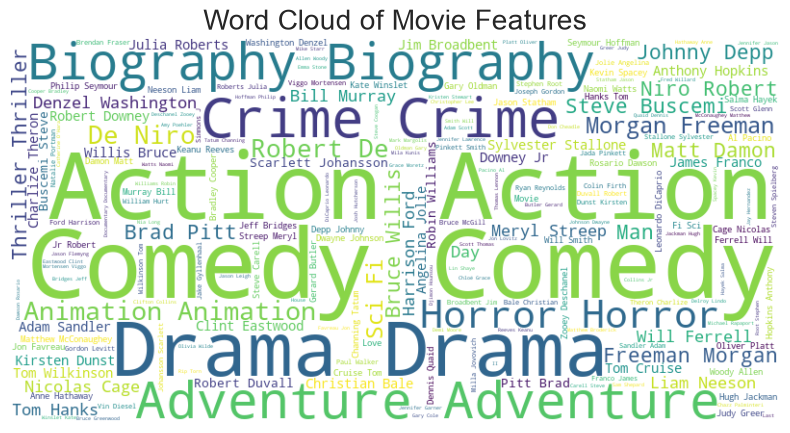

In [9]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Features', fontsize=20)
plt.show()

In [10]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /Users/karen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/karen/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/karen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
StopWords = set(stopwords.words('english'))

### Preprocessing the Combined Text Features

In [12]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in StopWords]
    return ' '.join(tokens)

In [13]:
movies["Cleaned_Combined"] = movies["Combined"].apply(preprocess_text)

In [14]:
tfidf = TfidfVectorizer(max_features=5000)
matrix = tfidf.fit_transform(movies['Cleaned_Combined'])
matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 37812 stored elements and shape (3902, 5000)>

In [15]:
similarity = cosine_similarity(matrix)
similarity.shape

(3902, 3902)

-----------
# Movie Recommendation System Function
-----------

In [16]:
def recommend_movies(movie_name, similarity=similarity):

    exact = movies[movies["Movie"].str.lower() == movie_name.lower()]

    if not exact.empty:
        idx = exact.index[0]

    else:
        matches = movies[movies["Movie"].str.contains(movie_name, case=False, na=False)]

        if matches.empty:
            return "Movie not found in the dataset."

        if len(matches) > 1:
            print("Found these movies:\n")

            for i, title in enumerate(matches["Movie"], start=1):
                print(f"{i}. {title}")

            choice = int(input("\nWhich one did you get at?(1-{}): ".format(len(matches))))

            idx = matches.index[choice - 1]

        else:
            idx = matches.index[0]

    distances = sorted(
        list(enumerate(similarity[idx])),
        key=lambda x: x[1],
        reverse=True
    )

    recommended_movies = []

    for i in distances[1:6]:
        movie = movies.iloc[i[0]]
        recommended_movies.append({
            "Movie": movie["Movie"],
            "Genre": movie["Genre"],
            "IMDb": movie["IMDb score"],
            "Similarity Score": round(i[1], 2)
        })

    recommendations = pd.DataFrame(recommended_movies)

    print(f"\n\nSimiliar Movies to '{movies.iloc[idx]['Movie']}':\n")
    for index, row in recommendations.iterrows():

        print(f"{row['Movie']} | {row['Genre']} | IMDb: {row['IMDb']} | Similarity Score: {row['Similarity Score']}")

    return

### Testing the Recommendation System with Different Movie Names

In [17]:
df[df["Movie"].str.contains("Pirates of the Caribbean", case=False, na=False)]

,Movie,Director,Running time,Actor 1,Actor 2,Actor 3,Genre,Budget,Box Office,Actors Box Office %,Director Box Office %,Earnings,Oscar and Golden Globes nominations,Oscar and Golden Globes awards,Release year,IMDb score
704,Pirates of the Caribbean: On Stranger Tides,Rob Marshall,136,Johnny Depp,Sam Claflin,Stephen Graham,Action,250000000,1046000000,85.55,60.00,796000000,0,0.0,2011,6.7
1659,Pirates of the Caribbean: At World's End,Gore Verbinski,169,Johnny Depp,Orlando Bloom,Jack Davenport,Action,300000000,963000000,52.25,57.14,663000000,2,0.0,2007,7.1
1752,Pirates of the Caribbean: Dead Man's Chest,Gore Verbinski,151,Johnny Depp,Orlando Bloom,Jack Davenport,Action,225000000,1066000000,52.25,57.14,841000000,4,1.0,2006,7.3
1814,Pirates of the Caribbean: The Curse of the Bla...,Gore Verbinski,143,Johnny Depp,Orlando Bloom,Jack Davenport,Action,140000000,654000000,52.25,57.14,514000000,6,1.0,2003,8.1


### Movie 1

In [18]:
movie_name = "Pirates of the Caribbean: The Curse of the Black Pearl"
recommend_movies(movie_name)



Similiar Movies to 'Pirates of the Caribbean: The Curse of the Black Pearl':

Pirates of the Caribbean: Dead Man's Chest | Action | IMDb: 7.3 | Similarity Score: 0.88
Pirates of the Caribbean: At World's End | Action | IMDb: 7.1 | Similarity Score: 0.88
Kingdom of Heaven | Action | IMDb: 7.2 | Similarity Score: 0.42
The Lord of the Rings: The Fellowship of the Ring | Action | IMDb: 8.8 | Similarity Score: 0.4
The Lord of the Rings: The Two Towers | Action | IMDb: 8.7 | Similarity Score: 0.39


### Movie 2

In [19]:
movie_name = "iron"
recommend_movies(movie_name)

Found these movies:

1. Gridiron Gang
2. Iron Man 2
3. Iron Man 3
4. The Iron Giant
5. Iron Man
6. The Man in the Iron Mask
7. Ironclad
8. The Iron Lady
9. The Man with the Iron Fists


Similiar Movies to 'Iron Man 2':

Iron Man 3 | Action | IMDb: 7.2 | Similarity Score: 0.7
Iron Man | Action | IMDb: 7.9 | Similarity Score: 0.7
Captain America: Civil War | Action | IMDb: 8.2 | Similarity Score: 0.52
The Avengers | Action | IMDb: 8.1 | Similarity Score: 0.52
Avengers: Age of Ultron | Action | IMDb: 7.5 | Similarity Score: 0.5
